In [1]:
# Experiment: IMAX LASER - Integrated Multimodal Analysis & XFEL: Laser Ablation Surgery Efficacy Research
# Proposal Number: 007699
# PI: I. Bitharas
# Example of manual harwest of image data 
# Simple SVD normalisation applied data stitched and videos saved (intermediate jpg files) 
# SVD on flat fielts was done separately here we load truncated matrixes for simplicity stored in numpy arrays 
# P.V. 18.4.2025

## TKM 01/05/2025: straightforward low-cell code to work with a single image

In [2]:
## stackview is no longer needed (it was imported but never used)

In [3]:
from extra_data import RunDirectory 
import extra_data # EuXFEL library for data reading sorting ... 
import extra_data.components as edc
from matplotlib import pyplot as plt
#import stackview # ploting stack views with sliders
import numpy as np
import glob
#from natsort import natsorted
import os
import subprocess
from ipywidgets import interact, IntSlider


import sys

# in case this file is in the notebook folder can be commented out

from svd_on_datasets import ImageSVD
from tqdm import tqdm

In [4]:
folder = '/gpfs/exfel/exp/SPB/202501/p007699/raw'

# Updated path to save annotated truncated matrixes, jpgs, and gifs
proc_folder = '/gpfs/exfel/exp/SPB/202501/p007699/usr/Shared/sbowie/foam_analysis'

### SaveImageSequence class

In [5]:
class SaveImageSequence(object):
    """
     For saving image data runs 
     
    """
    def __init__(self,Iseq): ### on init provide data
        self.Iseq = Iseq
        print('Shape of input data: Iseq {}'.format(Iseq.shape))
        self.flag_saving_params_set = False
        self.flag_annotation_params_set = False

    def set_saving_params(self, run_num,folder,svd_rank_flats=50):
        """
        set_saving_params(run_num,folder,svd_rank_flats=50)
        """
        #folder ---> svd, from here i expect 
        # outputs go to <folder>/raw/: the .npy stack and the jpg folders
        # svd_rank_flats=50 change if you use other flats 
        
        self.run_num = run_num
        self.folder = folder

        print('Data will be saved here: ')
        self.fprefix = 'r{:03d}_svd_normalised_tr{:03d}'.format(run_num,svd_rank_flats)
        print('File prefix: {}'.format(self.fprefix))
        
        self.npyfile = os.path.join(folder,'raw',self.fprefix +'.npy')   # full-precision normalised stack
        print('Numpy file: {}'.format(self.npyfile) )
        
        self.jpgfolder = os.path.join(folder,'raw','jpg_{}'.format(self.fprefix))
        print('JPG: folder: {}'.format(self.jpgfolder))
        self.jpgfolder_annotated = self.jpgfolder + '_annotated'
        print('Annotated JPG folder: {}'.format(self.jpgfolder_annotated))
        
        
        flag_saving_params_set = True

    def set_annotation_params(self,framing_time,pixel, scalebar_size, SBstart, time_pos ):
        """
        framing_time = 886e-9 # (s) for this experiment
        pixel = 3.2e-6 # (m)
        scalebar_size = 100e-6 # (m)
        ## position of scale bar and timestamps in pixels 
        SBstart = [355,230] ### start of the scale bar line 
        time_pos = [330,10] 
        usage:
        set_annotation_params(framing_time,pixel, scalebar_size, SBstart, time_pos )
        
        """
        
        
        self.framing_time = framing_time         # 886e-9 # framing time (s)
        self.pixel = pixel              # 3.2e-6      # Effective pixel size (m)
        self.line_size = scalebar_size # 100e-6 # Line size for scale bar (m) 
        

        #line start point
        self.lsx = SBstart[0]# 355   SBstart = [355,230]
        self.lsy = SBstart[1]# 230

        #time display position
        self.xt = time_pos[0] # 330 # time_pos [330,10]
        self.yt = time_pos[1] # 10 

        self.flag_annotation_params_set  = True



    def set_image_sequence(self,Iseq):
        self.Iseq = Iseq
        

    def save_numpy_array(self, skip_existing=True):
        if skip_existing and os.path.exists(self.npyfile):
            print('Numpy file exists, skipped: {}'.format(self.npyfile))
            return
        print('Saving numpy array to: {}'.format(self.npyfile) )
        os.makedirs(os.path.dirname(self.npyfile), exist_ok=True)
        np.save(self.npyfile,self.Iseq)
        
    def save_jpg_sequence(self,tid, tune=True, show=False):
        """
            Provide image sequence index tid:
            Iseq[tid,framenumber, y,x]
            
            tune = True --> setup annotations before saving all stack
            provide folder and file prefix to save npy and jpg files
        """
        
        if self.flag_annotation_params_set==False:
            print('Set parameters first: set_annotation_params(framing_time,pixel, scalebar_size, SBstart, time_pos )') 
            sys.exit(0)
            
        #create folder for jpgs 
        isExist = os.path.exists(self.jpgfolder)
        
        # create if not exists
        if not isExist:
            print('Directory {} does not exist ... creating_one'.format(self.jpgfolder))
            os.makedirs(self.jpgfolder)
            print("The new {} directory is created!".format(self.jpgfolder))
            
            
        fs = 16 # font size
        line_npix = int(self.line_size/self.pixel)      # number of pixels through the line
        x=[self.lsx,self.lsx+line_npix]
        y=[self.lsy,self.lsy]

    
        if tune==True:
            ## here annotationins on one image can be tuned
            plt.figure()
            plt.imshow(Iseq[tid,0,:,:],cmap='gray')
            #plot scale bar
            plt.plot(x,y,color='white',linewidth=3)
            plt.text(self.lsx-5,self.lsy+15,r'{:3.0f} $\mu$m'.format(self.line_size*1e6),color='white',fontsize=fs)
            plt.axis('off')
        
            plt.text(self.xt,self.yt,r'{:03.03f} $\mu$s'.format(self.framing_time*10*1e6),fontsize=fs,color='white')
            plt.show()
            sys.exit(0)

        else:
            print('Saving jpg files: {}'.format(self.jpgfolder))
            tm=0
            ll = np.arange(0,Iseq.shape[1],1)
            for i in tqdm(ll):
                plt.figure()
                plt.imshow(Iseq[tid,i,:,:],cmap='gray')
                plt.plot(x,y,color='white',linewidth=3)
                plt.text(self.lsx-5,self.lsy+15,r'{:3.0f} $\mu$m'.format(self.line_size*1e6),color='white',fontsize=fs)
                plt.axis('off')
                plt.text(self.xt,self.yt,r'{:03.03f} $\mu$s'.format(tm*1e6),fontsize=fs,color='white')
                ff = os.path.join(self.jpgfolder,'{}_tid{:01d}_{:03d}.jpg'.format(self.fprefix,tid,i))
                #print('Saving file: {}'.format(ff))
                plt.savefig(ff, bbox_inches='tight', transparent=True,pad_inches=0,dpi=300)
                #plt.show() #uncomment if you want to see images
                if show:          # only display when the caller asks
                    plt.show()
                else:             # suppress notebook output
                    plt.close()   # <- add this line
                tm = tm+self.framing_time #increment total time (s)



    def annotated_images(self, tid, frame_no):
        fs = 16 # font size
        
        line_npix = int(self.line_size/self.pixel)      # number of pixels through the line
        x=[self.lsx,self.lsx+line_npix]
        y=[self.lsy,self.lsy]
        
        plt.figure(figsize=(10,10))
        plt.imshow(Iseq[tid,frame_no,:,:],cmap='gray')
        plt.title(f"Train {tid}  |  frame {frame_no}")
        plt.plot(x,y,color='white',linewidth=3)
        plt.text(self.lsx-5,self.lsy+15,r'{:3.0f} $\mu$m'.format(self.line_size*1e6),color='white',fontsize=fs)
        plt.axis('off')
        plt.text(self.xt,self.yt,r'{:03.03f} $\mu$s'.format(self.framing_time*frame_no*1e6),fontsize=fs,color='white')
        plt.show()

    def annotated_images_slider(self, t, p):
        self.annotated_images(t, p)

    def global_display_range(self, percentiles=(0.5, 99.5), max_samples=5_000_000, seed=0):
        """
        One fixed grey-level range for the WHOLE sequence (all trains, all frames).
        The old matplotlib export autoscaled every frame to its own min/max, which makes the
        brightness jump from frame to frame. A fixed range keeps the SVD-normalised
        intensities comparable over time.
        """
        data = self.Iseq[np.isfinite(self.Iseq)]
        if data.size > max_samples:
            data = np.random.default_rng(seed).choice(data, max_samples, replace=False)
        vmin, vmax = np.percentile(data, percentiles)
        print('Display range (percentiles {}): vmin={:.4f}, vmax={:.4f}'.format(percentiles, vmin, vmax))
        return float(vmin), float(vmax)

    def save_clean_sequence(self, tid, vmin, vmax, jpg_quality=95, save_tiff16=False, skip_existing=True):
        """
        Save every frame of train tid at NATIVE sensor resolution (e.g. 400 x 250 px),
        WITHOUT scale bar or timestamp. Same folder and file names as save_jpg_sequence,
        so the old annotated JPGs are overwritten.
            vmin, vmax   : fixed grey-level range (see global_display_range)
            jpg_quality  : JPEG quality (95 = visually lossless)
            save_tiff16  : additionally save a lossless 16-bit TIFF (tiff_<prefix>/ folder)
            skip_existing: do not rewrite files that already exist
        Pixel size for analysis: self.pixel (m/px); time between frames: self.framing_time (s).
        """
        from PIL import Image
        os.makedirs(self.jpgfolder, exist_ok=True)
        if save_tiff16:
            tiff_folder = self.jpgfolder.replace('jpg_', 'tiff_')
            os.makedirs(tiff_folder, exist_ok=True)
        scaled = np.clip((self.Iseq[tid] - vmin) / (vmax - vmin), 0, 1)
        scaled = np.nan_to_num(scaled, nan=0.0)
        written = skipped = 0
        for i in tqdm(range(scaled.shape[0])):
            name = '{}_tid{:01d}_{:03d}'.format(self.fprefix, tid, i)
            jpg = os.path.join(self.jpgfolder, name + '.jpg')
            if skip_existing and os.path.exists(jpg):
                skipped += 1
            else:
                Image.fromarray(np.round(scaled[i] * 255).astype(np.uint8), mode='L').save(
                    jpg, quality=jpg_quality, subsampling=0)
                written += 1
            if save_tiff16:
                tif = os.path.join(tiff_folder, name + '.tif')
                if not (skip_existing and os.path.exists(tif)):
                    Image.fromarray(np.round(scaled[i] * 65535).astype(np.uint16)).save(tif)
        print(f'  clean: {written} written, {skipped} already existed')

    def render_annotated(self, frame01, frame_no, scale=5):
        """
        One frame (values already scaled to 0..1) -> PIL image upsampled `scale` x, with the scale bar
        and time stamp drawn at the positions set in set_annotation_params (same layout as the old
        matplotlib export, but fast and with the fixed grey-level range).
        """
        from PIL import Image, ImageDraw, ImageFont
        from matplotlib import font_manager
        h, w = frame01.shape
        im = Image.fromarray(np.round(np.nan_to_num(frame01) * 255).astype(np.uint8), mode='L')
        im = im.resize((w * scale, h * scale), Image.BICUBIC).convert('RGB')
        draw = ImageDraw.Draw(im)
        font = ImageFont.truetype(font_manager.findfont('DejaVu Sans'), size=int(13 * scale))
        ascent, descent = font.getmetrics()
        px = lambda v: (v + 0.5) * scale            # data pixel coordinate -> output pixel
        W = w * scale

        def text_inside(x, y, txt):
            # draw left-baseline text at (x, y), shifted left if it would run off the right edge
            right = draw.textbbox((x, y), txt, font=font, anchor='ls')[2]
            draw.text((x - max(0, right - (W - 6)), y), txt, fill='white', font=font, anchor='ls')
        # scale bar
        line_npix = self.line_size / self.pixel
        lw = max(2, int(round(0.5 * scale)))
        draw.rectangle([px(self.lsx), px(self.lsy) - lw, px(self.lsx + line_npix), px(self.lsy) + lw], fill='white')
        label = '{:3.0f} \u00b5m'.format(self.line_size * 1e6).strip()
        yb = min(px(self.lsy + 15), h * scale - descent - 2)
        text_inside(px(self.lsx - 5), yb, label)
        # time stamp (time of this frame within the train)
        stamp = '{:03.03f} \u00b5s'.format(frame_no * self.framing_time * 1e6)
        text_inside(px(self.xt), max(px(self.yt), ascent + 2), stamp)
        return im

    def save_annotated_sequence(self, tid, vmin, vmax, scale=5, jpg_quality=95, skip_existing=True):
        """
        Save every frame of train tid WITH scale bar + time stamp into self.jpgfolder_annotated
        (same file names as the clean frames). Upsampled `scale` x so the text is readable
        (scale=5 gives 2000 x 1250 px, like the old export). For figures/presentations only;
        use the clean frames for analysis.
        """
        os.makedirs(self.jpgfolder_annotated, exist_ok=True)
        scaled = np.clip((self.Iseq[tid] - vmin) / (vmax - vmin), 0, 1)
        written = skipped = 0
        for i in tqdm(range(scaled.shape[0])):
            out = os.path.join(self.jpgfolder_annotated, '{}_tid{:01d}_{:03d}.jpg'.format(self.fprefix, tid, i))
            if skip_existing and os.path.exists(out):
                skipped += 1
                continue
            self.render_annotated(scaled[i], i, scale).save(out, quality=jpg_quality, subsampling=0)
            written += 1
        print(f'  annotated: {written} written, {skipped} already existed')


### Process the run

In [8]:
#Load flat decomposition for cameras 6 and 4 

## ENTER CLOSEST FLAT FIELD RUN NUMBER HERE -- THEY ARE ALL PROCESSED AND READY FOR REFERENCING
flat_num = 547

cam4_svd_flat = ImageSVD() 
cam6_svd_flat = ImageSVD() 


# Load saved svd decompositions of flat fields for data normalisation
cam4_svd_flat.read_truncated_model('/gpfs/exfel/exp/SPB/202501/p007699/scratch/svd/cam4_svd_r{}_tr050.h5'.format(flat_num))
cam6_svd_flat.read_truncated_model('/gpfs/exfel/exp/SPB/202501/p007699/scratch/svd/cam6_svd_r{}_tr050.h5'.format(flat_num))

## Load image sequence for normalisation

## ENTER RUN NUMBER 
run_num = 562
run = RunDirectory("{}/r{}".format(folder,str(run_num).zfill(4)))

# load and flip data and convert uint16 to double
Cam4 = np.float64(np.flip(np.flip(run.get_array('SPB_EHD_MIC/CAM/HPVX2_4:daqOutput','data.image.pixels').data,axis=3), axis=2))
Cam6 = np.float64(np.flip(run.get_array('SPB_EHD_MIC/CAM/HPVX2_6:daqOutput','data.image.pixels').data,axis=2 ))
# remove overlap and noisy frames
c6c = np.copy(Cam6[:,4:-1,:,:])
c4c = np.copy(Cam4[:,2:-1,:,:])
print('Cam4 shape: {}'.format(Cam4.shape))
print('Cam6 shape: {}'.format(Cam6.shape))
#### normalise whole set
print('c6 data: {}'.format(c6c.shape))
print('c4 data: {}'.format(c4c.shape))

# normalised data (Image/FlatField reconstructed)
c4n = np.zeros_like(c4c)
c6n = np.zeros_like(c6c)

#reconstructed flat fields
c4f = np.zeros_like(c4c)
c6f = np.zeros_like(c6c)

# normalise whole buffers
for i in range(c4c.shape[0]):
    for j in range(c4c.shape[1]):
        c4f[i,j,:,:] =  cam4_svd_flat.reconstruct(c4c[i,j,:,:])
        c4n[i,j,:,:] = np.divide(c4c[i,j,:,:],c4f[i,j,:,:])
         
print('normalising camera 4 done')
for i in range(c6c.shape[0]):
    for j in range(c6c.shape[1]):
        c6f[i,j,:,:] =  cam6_svd_flat.reconstruct(c6c[i,j,:,:])
        c6n[i,j,:,:] = np.divide(c6c[i,j,:,:],c6f[i,j,:,:])
print('normalising camera 6 done')

#Combine videos
# combined buffer do svd on combined buffer
#c6 data: (5, 123, 250, 400)
#c4 data: (5, 125, 250, 400)

Iseq = np.zeros( (c4n.shape[0],c4n.shape[1] + c6n.shape[1], c4n.shape[2], c4n.shape[3]),dtype=np.float64)
Iseq[:,0:c6n.shape[1],:,:] = c6n
Iseq[:,c6n.shape[1]:Iseq.shape[1],:,:] = c4n

### Save Sequence to npy file and select video for animation 
### using tid index
#Iseq.shape
sic = SaveImageSequence(Iseq)

sic.set_saving_params(run_num,proc_folder,svd_rank_flats=50)

framing_time = 886e-9 # (s) for this experiment
pixel = 3.2e-6 # (m)
scalebar_size = 100e-6 # (m)
## position of scale bar and timestamps in pixels 
SBstart = [355,230] ### start of the scale bar line 
time_pos = [330,10] 
sic.set_annotation_params(framing_time,pixel, scalebar_size, SBstart, time_pos )

n_trains = Iseq.shape[0]
frames_per_train = Iseq.shape[1]
# interact(sic.annotated_images_slider,
# t=IntSlider(0, 0, n_trains-1, 1, description="train"),
# p=IntSlider(0, 0, frames_per_train-1, 1, description="frame"));  


Trying to read file /gpfs/exfel/exp/SPB/202501/p007699/scratch/svd/cam4_svd_r547_tr050.h5
Reading done
Trying to read file /gpfs/exfel/exp/SPB/202501/p007699/scratch/svd/cam6_svd_r547_tr050.h5
Reading done
Cam4 shape: (9, 128, 250, 400)
Cam6 shape: (9, 128, 250, 400)
c6 data: (9, 123, 250, 400)
c4 data: (9, 125, 250, 400)
normalising camera 4 done
normalising camera 6 done
Shape of input data: Iseq (9, 248, 250, 400)
Data will be saved here: 
File prefix: r562_svd_normalised_tr050
Numpy file: /gpfs/exfel/exp/SPB/202501/p007699/usr/Shared/sbowie/foam_analysis/raw/r562_svd_normalised_tr050.npy
JPG: folder: /gpfs/exfel/exp/SPB/202501/p007699/usr/Shared/sbowie/foam_analysis/raw/jpg_r562_svd_normalised_tr050
Annotated JPG folder: /gpfs/exfel/exp/SPB/202501/p007699/usr/Shared/sbowie/foam_analysis/raw/jpg_r562_svd_normalised_tr050_annotated


### Export images: clean (for analysis) and annotated (for figures)

Everything is written to `<proc_folder>/raw/`: two copies of every frame (same file names, separate folders) and
the full-precision `.npy` stack:

| folder | content | use |
|---|---|---|
| `jpg_<prefix>/` | native 400×250 px, **no** annotations | analysis (training / inference notebooks read these) |
| `jpg_<prefix>_annotated/` | upsampled ×`ANNOT_SCALE` (5 → 2000×1250 px) with scale bar + time stamp | figures, presentations |
| `<prefix>.npy` | all trains × frames as float64 (8 × 248 × 250 × 400 ≈ 1.6 GB), before 8-bit conversion | optional, `SAVE_NPY` |

Both use one fixed grey-level range for the whole run, so the brightness does not flicker between frames. The flicker
correction itself is the SVD flat-field normalisation in the cell above. Scale bar / time-stamp positions come from
`set_annotation_params` (`SBstart`, `time_pos`, in native pixels). Check them with the preview before exporting.
For analysis: pixel size = `pixel` (3.2 µm/px), frame interval = `framing_time` (886 ns).

### Export images

Display range (percentiles (0.5, 99.5)): vmin=0.1331, vmax=0.7353


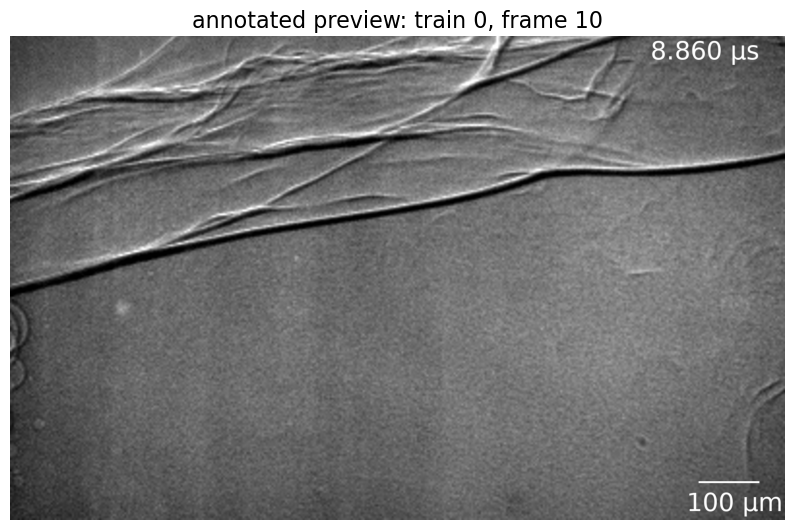

In [11]:
SAVE_NPY = True          # full-precision stack in raw/ (~1.6 GB); not used by the bubble notebooks
SAVE_CLEAN = True        # native-resolution frames without annotations (analysis)
SAVE_ANNOTATED = True    # upsampled frames with scale bar + time stamp (figures)
ANNOT_SCALE = 5          # upsampling of the annotated copies (5 -> 2000 x 1250 px)
SAVE_TIFF16 = False      # True: also write lossless 16-bit TIFFs of the clean frames (folder tiff_<prefix>)
JPG_QUALITY = 95
PREVIEW_ONLY = True     # True: only show the annotated preview below (check scale bar / time stamp positions)
SKIP_EXISTING = True     # True: files that already exist are not rewritten; False: overwrite everything

# one fixed grey-level range for all trains/frames (prevents brightness flicker between frames)
vmin, vmax = sic.global_display_range(percentiles=(0.5, 99.5))

# preview of an annotated frame
PREVIEW_TRAIN, PREVIEW_FRAME = 0, min(10, sic.Iseq.shape[1] - 1)
prev = sic.render_annotated(np.clip((sic.Iseq[PREVIEW_TRAIN, PREVIEW_FRAME] - vmin) / (vmax - vmin), 0, 1), PREVIEW_FRAME, ANNOT_SCALE)
plt.figure(figsize=(10, 6.5)); plt.imshow(prev); plt.axis('off')
plt.title(f'annotated preview: train {PREVIEW_TRAIN}, frame {PREVIEW_FRAME}'); plt.show()

if not PREVIEW_ONLY:
    if SAVE_NPY:
        sic.save_numpy_array(skip_existing=SKIP_EXISTING)
    n_trains = sic.Iseq.shape[0]
    for tid in range(n_trains):
        print(f"Train {tid + 1}/{n_trains}")
        if SAVE_CLEAN:
            sic.save_clean_sequence(tid, vmin, vmax, jpg_quality=JPG_QUALITY, save_tiff16=SAVE_TIFF16, skip_existing=SKIP_EXISTING)
        if SAVE_ANNOTATED:
            sic.save_annotated_sequence(tid, vmin, vmax, scale=ANNOT_SCALE, jpg_quality=JPG_QUALITY, skip_existing=SKIP_EXISTING)
    print('clean frames:    ', sic.jpgfolder)
    print('annotated frames:', sic.jpgfolder_annotated)